# 🌍💹 NOTEBOOK DE RYAN LE MACROECONOMISTE 	🌍💹

## === GUIDE des fonctions du module local datalake === 

from DATALAKE.data import *

**data = data_download_gmd("country")** -> Telechargement des données liés à un pays via global_macro_dataset (BD publique)
**data = data_download_fred("indicator"** : str, "start" : str , "end" : str) -> Telechargement d'un indicateur via la FRED (BD publique)

**data_storing(data : dataframe, "nom_fichier" : str)** -> Range un dataframe "data" dans le DATALAKE en parquet, que vous venez de télécharger d'internet 

**data = import_parquet("file_name" : str)** -> importe un dataframe du DATALAKE dans votre file cible (notebook ou .py)

**which_parquet()** -> Vous renvoie une liste de l'ensemble des parquets dispo dans le DATALAKE

## === Pour importer les fonctions du fichier "outils_eda", si vous en avez besoin lors de votre analyse ===

import sys
import os

sys.path.append("../dorian_code") -> permet à Python d'aller lire les fichiers présent dans le dossier "dorian_code"

from outils_eda import * -> importe le fichier "outils_eda" dont ces fonctions que vous pouvez utiliser lors de l'analyse !

In [9]:
#Dans cette cell j'importe tous les modules dont j'ai besoin
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR

In [10]:
#Dans cette cell je prends connaisance des données et des différentes variables, elle me sert à me situer
import pandas as pd
path_parquet_file = '/Users/Ryan/economic_research/DATALAKE/PARQUET_FOLDER/main_detrended.parquet'
df_detrended = pd.read_parquet(path_parquet_file)
# Donne un résumé technique du DataFrame
df_detrended.info()


<class 'pandas.core.frame.DataFrame'>
Index: 105 entries, 12 to 174
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  105 non-null    float64
 1   gdp_nominal           105 non-null    float64
 2   expected_inflation    105 non-null    float64
 3   taux_changes          105 non-null    float64
 4   cpi                   105 non-null    float64
 5   taux_directeur        105 non-null    float64
 6   export                105 non-null    float64
 7   import                105 non-null    float64
 8   yield_perpetual       105 non-null    float64
 9   oil_price             105 non-null    float64
 10  gdp_cycle             105 non-null    float64
 11  gdp_trend             105 non-null    float64
 12  output_gap            105 non-null    float64
 13  taux_changes_stat     105 non-null    float64
 14  yield_perpetual_stat  105 non-null    float64
 15  gdp_nominal_stat      105 n

In [11]:
#Le problème avec un modèle VAR est qu'il est impossible d'isoler l'effet d'un choc pur de politique monétaire, car toute les variables interagissent. 
#simultanément. Ainsi, pour passer d'un modèle VAR à SVAR on utilise la décomposition de Cholesky. L'objectif est de classer les variables de la plus 
#lente à réagir à la plus rapide.
variables_svar = ['oil_price_stat', 'output_gap', 'cpi_stat', 'taux_directeur', 'taux_changes_stat']

# Découpage temporel et appliquation de la matrice de Cholesky
df_gold = df_detrended[df_detrended['year'] < 1914].set_index('year')[variables_svar]
df_bw = df_detrended[(df_detrended['year'] >= 1945) & (df_detrended['year'] <= 1973)].set_index('year')[variables_svar]
df_float = df_detrended[df_detrended['year'] > 1973].set_index('year')[variables_svar]

display(df_gold)

,oil_price_stat,output_gap,cpi_stat,taux_directeur,taux_changes_stat
year,,,,,
1862.0,0.762139,-22.973469,-0.026344,3.0,0.78500
1863.0,1.098612,94.847245,-0.036664,7.0,1.51650
1864.0,0.939511,33.020206,-0.009041,6.0,2.89975
1865.0,-0.201360,102.844247,0.008960,7.0,-2.28275
1866.0,-0.566468,101.254027,0.062975,3.5,-0.81475
1869.0,0.002751,-17.914729,-0.051293,3.0,-0.34450
1870.0,0.058683,-48.698207,0.000000,2.5,-0.89500
1871.0,0.117207,45.235233,0.013903,3.0,-0.12800
1872.0,-0.175891,18.833091,0.045929,5.0,-0.01550


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


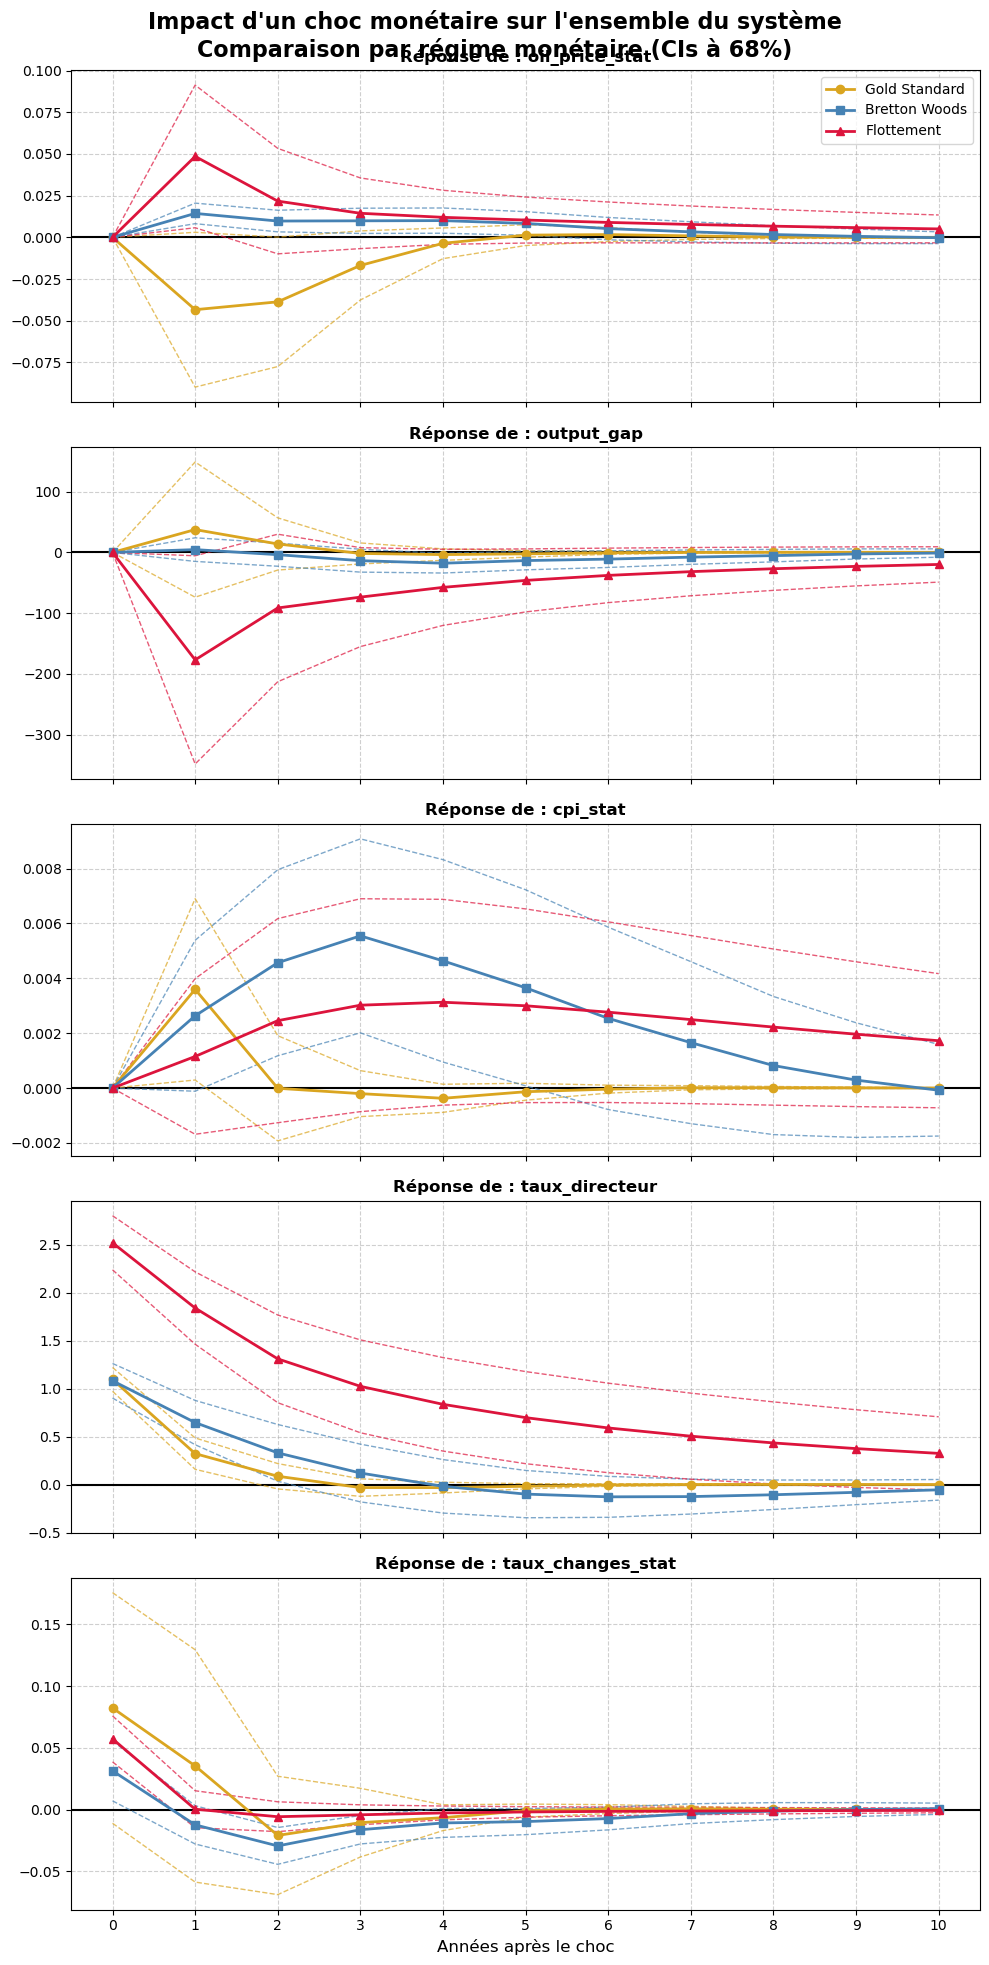

In [20]:
# J'estime un modèle VAR pour chaque période distincte. 
# J'applique un retard (lag) de 1 an, car je suppose que l'économie de l'année 't' 
# dépend des conditions macroéconomiques de l'année 't-1'.
res_gold = VAR(df_gold).fit(1)
res_bw = VAR(df_bw).fit(1)
res_float = VAR(df_float).fit(1)

# Je fixe mon horizon d'analyse à 10 ans pour observer les effets de moyen et long terme.
horizon = 10

# Je demande à l'algorithme de simuler un choc structurel et de calculer la 
# trajectoire de l'ensemble de mes variables sur cette période de 10 ans.
irf_gold = res_gold.irf(horizon)
irf_bw = res_bw.irf(horizon)
irf_float = res_float.irf(horizon)

# Je récupère la liste de mes variables et j'identifie la position exacte de la 
# variable qui va causer le choc dans mon scénario (ici, le taux directeur).
var_names = res_float.names 
idx_choc = var_names.index('taux_directeur')

# Je définis mes choix esthétiques pour différencier visuellement mes trois époques.
couleurs = {'Gold Standard': 'goldenrod', 'Bretton Woods': 'steelblue', 'Flottement': 'crimson'}
marqueurs = {'Gold Standard': 'o', 'Bretton Woods': 's', 'Flottement': '^'}

# Je prépare une grande figure contenant un sous-graphique (axe) pour chaque variable étudiée.
fig, axes = plt.subplots(nrows=len(var_names), ncols=1, figsize=(10, 20), sharex=True)
fig.suptitle("Impact d'un choc monétaire sur l'ensemble du système\nComparaison par régime monétaire (CIs à 68%)", 
             fontsize=16, fontweight='bold', y=0.98)

# Je choisis z=1 pour calculer mes intervalles de confiance à environ 68% (soit +/- un écart-type),
# ce qui est une norme adaptée pour obtenir des résultats lisibles sur des séries historiques de petite taille.
z = 1

# Je crée une boucle qui va générer les graphiques variable par variable.
for i, var_reponse in enumerate(var_names):
    idx_reponse = var_names.index(var_reponse)
    ax = axes[i]
    
    # C'est l'étape importante : j'utilise 'orth_irfs' pour appliquer ma matrice de Cholesky.
    # Cela me permet de "nettoyer" les résidus statistiques et d'isoler l'impact pur de mon choc de politique monétaire.
    valeurs_gold = irf_gold.orth_irfs[:, idx_reponse, idx_choc]
    valeurs_bw = irf_bw.orth_irfs[:, idx_reponse, idx_choc]
    valeurs_float = irf_float.orth_irfs[:, idx_reponse, idx_choc]
    
    # J'extrais l'erreur standard calculée par le modèle (toujours sous l'hypothèse d'orthogonalisation).
    # Puis, je calcule manuellement mes bornes hautes et basses.
    se_gold = irf_gold.stderr(orth=True)[:, idx_reponse, idx_choc]
    lower_gold, upper_gold = valeurs_gold - z * se_gold, valeurs_gold + z * se_gold
    
    se_bw = irf_bw.stderr(orth=True)[:, idx_reponse, idx_choc]
    lower_bw, upper_bw = valeurs_bw - z * se_bw, valeurs_bw + z * se_bw
    
    se_float = irf_float.stderr(orth=True)[:, idx_reponse, idx_choc]
    lower_float, upper_float = valeurs_float - z * se_float, valeurs_float + z * se_float
    
    # Je trace la ligne zéro qui me sert de référence de base (aucun impact économique).
    ax.axhline(0, color='black', linewidth=1.5)
    
    # Je trace mes intervalles de confiance en pointillés fins pour ne pas surcharger la lecture.
    ax.plot(lower_gold, color=couleurs['Gold Standard'], linestyle='--', linewidth=1, alpha=0.7)
    ax.plot(upper_gold, color=couleurs['Gold Standard'], linestyle='--', linewidth=1, alpha=0.7)
    ax.plot(lower_bw, color=couleurs['Bretton Woods'], linestyle='--', linewidth=1, alpha=0.7)
    ax.plot(upper_bw, color=couleurs['Bretton Woods'], linestyle='--', linewidth=1, alpha=0.7)
    ax.plot(lower_float, color=couleurs['Flottement'], linestyle='--', linewidth=1, alpha=0.7)
    ax.plot(upper_float, color=couleurs['Flottement'], linestyle='--', linewidth=1, alpha=0.7)
    
    # Je trace enfin mes trajectoires principales (les moyennes des IRF) avec une ligne épaisse.
    ax.plot(valeurs_gold, label='Gold Standard', color=couleurs['Gold Standard'], linewidth=2, marker=marqueurs['Gold Standard'])
    ax.plot(valeurs_bw, label='Bretton Woods', color=couleurs['Bretton Woods'], linewidth=2, marker=marqueurs['Bretton Woods'])
    ax.plot(valeurs_float, label='Flottement', color=couleurs['Flottement'], linewidth=2, marker=marqueurs['Flottement'])
    
    # J'ajoute les titres et j'active la grille pour faciliter la lecture des points de données.
    ax.set_title(f"Réponse de : {var_reponse}", fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Je n'affiche la légende que sur le premier graphique pour éviter les répétitions.
    if i == 0:
        ax.legend(loc='upper right', fontsize=10)

# J'ajuste les axes, le nom des années, et je gère l'espacement global de la figure avant de l'afficher.
plt.xlabel("Années après le choc", fontsize=12)
plt.xticks(range(0, horizon + 1))
plt.tight_layout()
plt.subplots_adjust(top=0.95) 
plt.show()

1. Le choc initial

   À l'année 0, on observe bien un choc positif (une hausse surprise des taux). Le modèle fonctionne donc!!

    La dynamique du choc est très différente selon les époques. Sous le Flottement (rouge), la hausse des taux est très forte (presque +2.5) et surtout très persistante (il faut près de 10 ans pour que l'effet se dissipe totalement). Sous l'Étalon-Or (jaune) et Bretton Woods (bleu), le choc est plus faible (+1) et s'estompe très rapidement (en 2 ou 3 ans).

2. L'économie réelle (Output Gap)

    La ligne rouge (Flottement) plonge violemment vers -180 l'année suivant le choc, et l'intervalle de confiance pointillé reste sous la ligne zéro pendant plusieurs années. En revanche, les lignes jaune et bleue restent collées à zéro.

    Dans l'économie moderne (Flottement), la politique monétaire a un impact réel massif et immédiat : monter les taux étouffe l'investissement et la consommation, créant une récession. Sous l'Étalon-Or et Bretton Woods, monter les taux n'avait presque aucun effet direct ou significatif sur l'activité domestique 

3. L'inflation (CPI Stat)

    Observation : Sous Bretton Woods et le Flottement, l'inflation monte suite à la hausse des taux. Sous l'Étalon-Or, elle stagne ou baisse légèrement.

    La théorie dit qu'une hausse des taux doit faire baisser l'inflation. Le fait que les courbes rouge et bleue montent s'appelle le "Price Puzzle" (l'énigme des prix). C'est un phénomène extrêmement courant dans les modèles SVAR. Cela s'explique souvent parce que la Banque Centrale a des informations que le modèle n'a pas (elle monte les taux parce qu'elle sait que l'inflation va monter).

    En revanche, l'Étalon-Or réagit de manière plus "classique" : les prix étaient très flexibles à l'époque et s'ajustaient rapidement à la baisse sans rigidité.

4. La monnaie (Taux de change)

    Pour les trois régimes, le choc provoque une hausse immédiate (appréciation) du taux de change à l'année 0.

    C'est parfaitement conforme à la théorie économique (la théorie de la parité des taux d'intérêt). Quand une banque centrale monte ses taux, la monnaie devient plus rémunératrice, attirant les capitaux étrangers, ce qui fait s'apprécier la devise. On note que c'est sous l'Étalon-Or (jaune) que cette réaction instantanée est la plus violente, ce qui prouve que l'arme des taux servait avant tout à défendre la monnaie et les flux d'or, comme nous en avions discuté en IMF!

5. Le Pétrole (Oil Price)

   Les réactions sont assez hétérogènes et souvent non significatives (les intervalles croisent le zéro), sauf pour une légère baisse sous l'Étalon-Or et une hausse sous le Flottement.

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


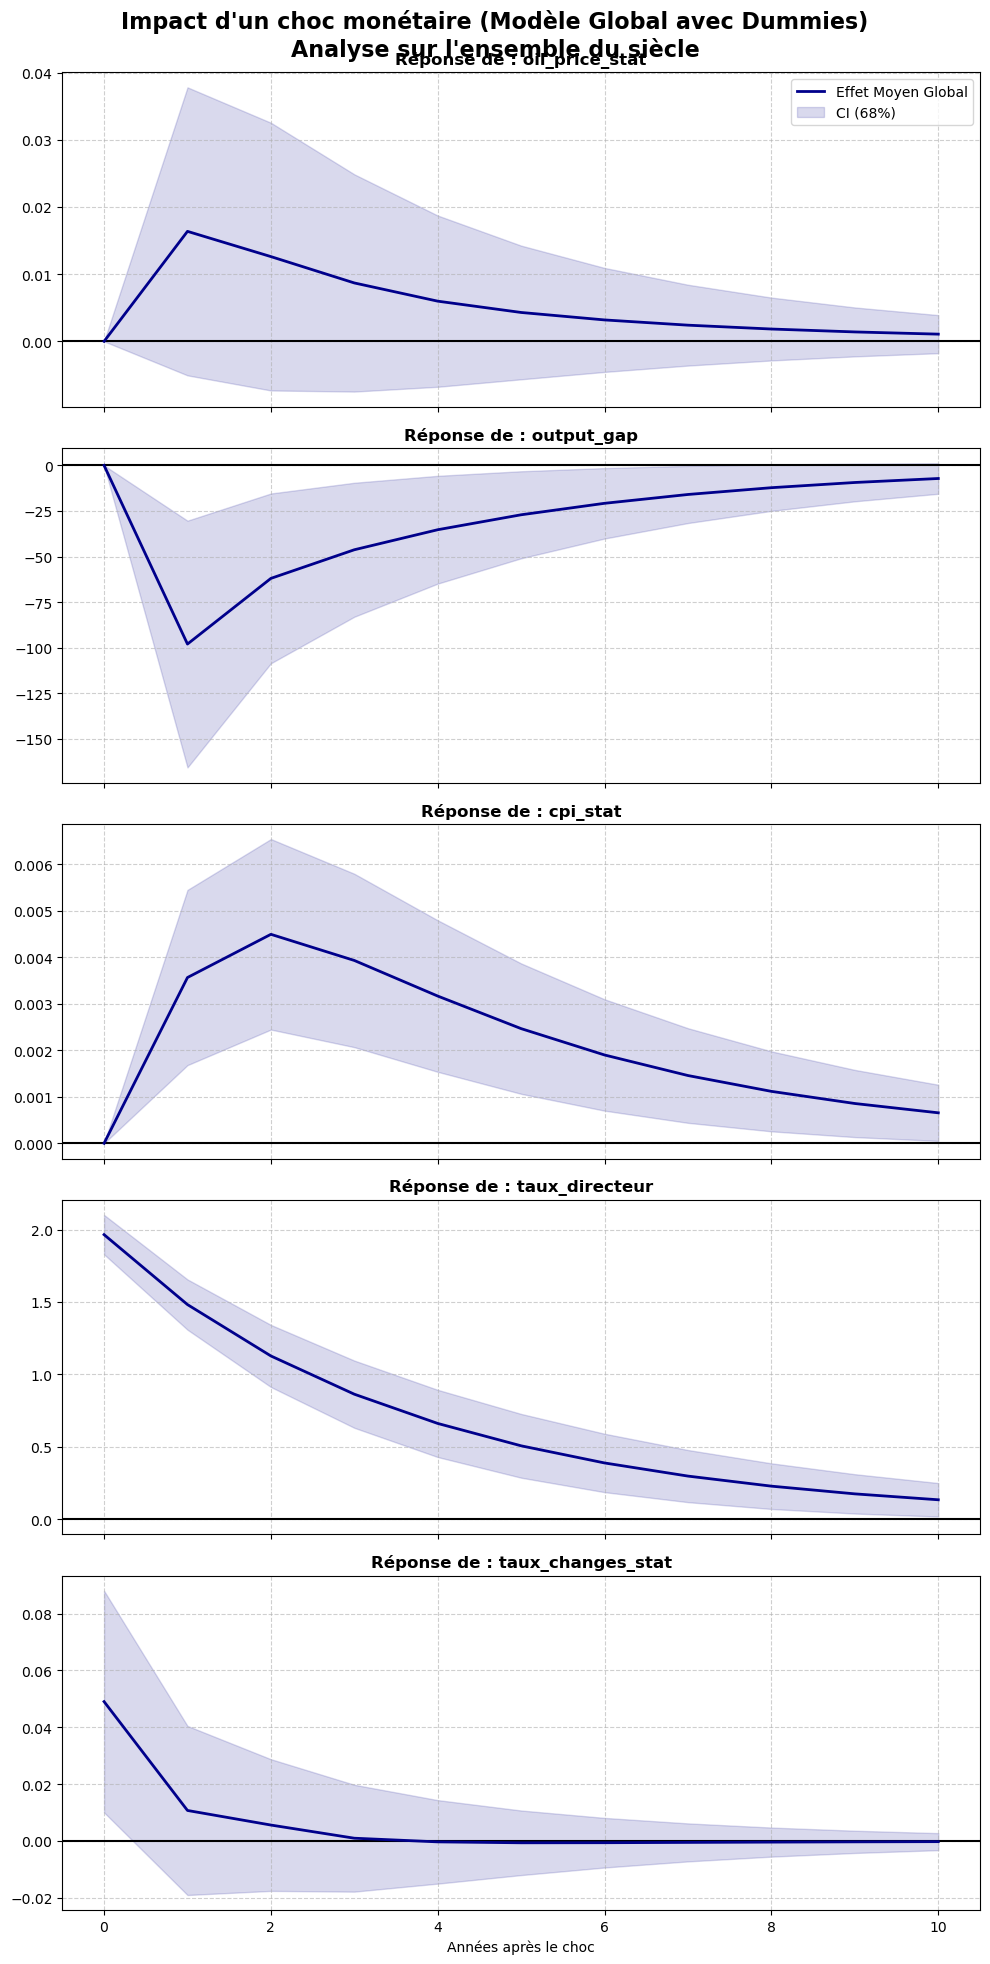

In [ ]:
#Ici j'essaie d'appliquer ce que le professeur nous a demandé, tout d'abord en ajoutant une variable dummies pour distinguer les périodes. 
import numpy as np

# Je crée des colonnes qui indiquent au modèle dans quel régime on se trouve.
df_detrended['dummy_gold'] = np.where(df_detrended['year'] < 1914, 1, 0)
df_detrended['dummy_bw'] = np.where((df_detrended['year'] >= 1945) & (df_detrended['year'] <= 1971), 1, 0)
df_detrended['dummy_float'] = np.where(df_detrended['year'] > 1971, 1, 0)

# Je prépare mes données
variables_svar = ['oil_price_stat', 'output_gap', 'cpi_stat', 'taux_directeur', 'taux_changes_stat']
variables_exog = ['dummy_gold', 'dummy_bw', 'dummy_float']

df_model = df_detrended.set_index('year')
data_endog = df_model[variables_svar]
data_exog = df_model[variables_exog]

# J'estime un seul VAR sur toute la période (100+ ans) en incluant les dummies.
res_global = VAR(data_endog, exog=data_exog).fit(1)

# Je génère les IRF pour ce modèle global
horizon = 10
irf_global = res_global.irf(horizon)

#Je génère les graphs
var_names = res_global.names
idx_choc = var_names.index('taux_directeur')

fig, axes = plt.subplots(nrows=len(var_names), ncols=1, figsize=(10, 20), sharex=True)
fig.suptitle("Impact d'un choc monétaire (Modèle Global avec Dummies)\nAnalyse sur l'ensemble du siècle", 
             fontsize=16, fontweight='bold', y=0.98)

z = 1 # Pour l'intervalle à 68%

for i, var_reponse in enumerate(var_names):
    idx_reponse = var_names.index(var_reponse)
    ax = axes[i]
    
    # 1. Extraction de la moyenne (Cholesky appliqué au modèle global)
    valeurs = irf_global.orth_irfs[:, idx_reponse, idx_choc]
    
    # 2. Calcul des intervalles de confiance
    se = irf_global.stderr(orth=True)[:, idx_reponse, idx_choc]
    lower, upper = valeurs - z * se, valeurs + z * se
    
    # 3. Tracé
    ax.axhline(0, color='black', linewidth=1.5)
    ax.plot(valeurs, color='darkblue', linewidth=2, label='Effet Moyen Global')
    ax.fill_between(range(horizon + 1), lower, upper, color='darkblue', alpha=0.15, label='CI (68%)')
    
    ax.set_title(f"Réponse de : {var_reponse}", fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.6)
    if i == 0: ax.legend()

plt.xlabel("Années après le choc")
plt.tight_layout()
plt.show()

Vraiment c'est top d'avoir des résultats plus signficatif, mais à quoi cela peut servir à notre travail ??? Puisqu'on estime un VAR, j'arrive pas à isoler l'effet dans chaque régime

Tentative d'estimation du VAR interagi à 15 variables...
Succès : Le modèle a été estimé !


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


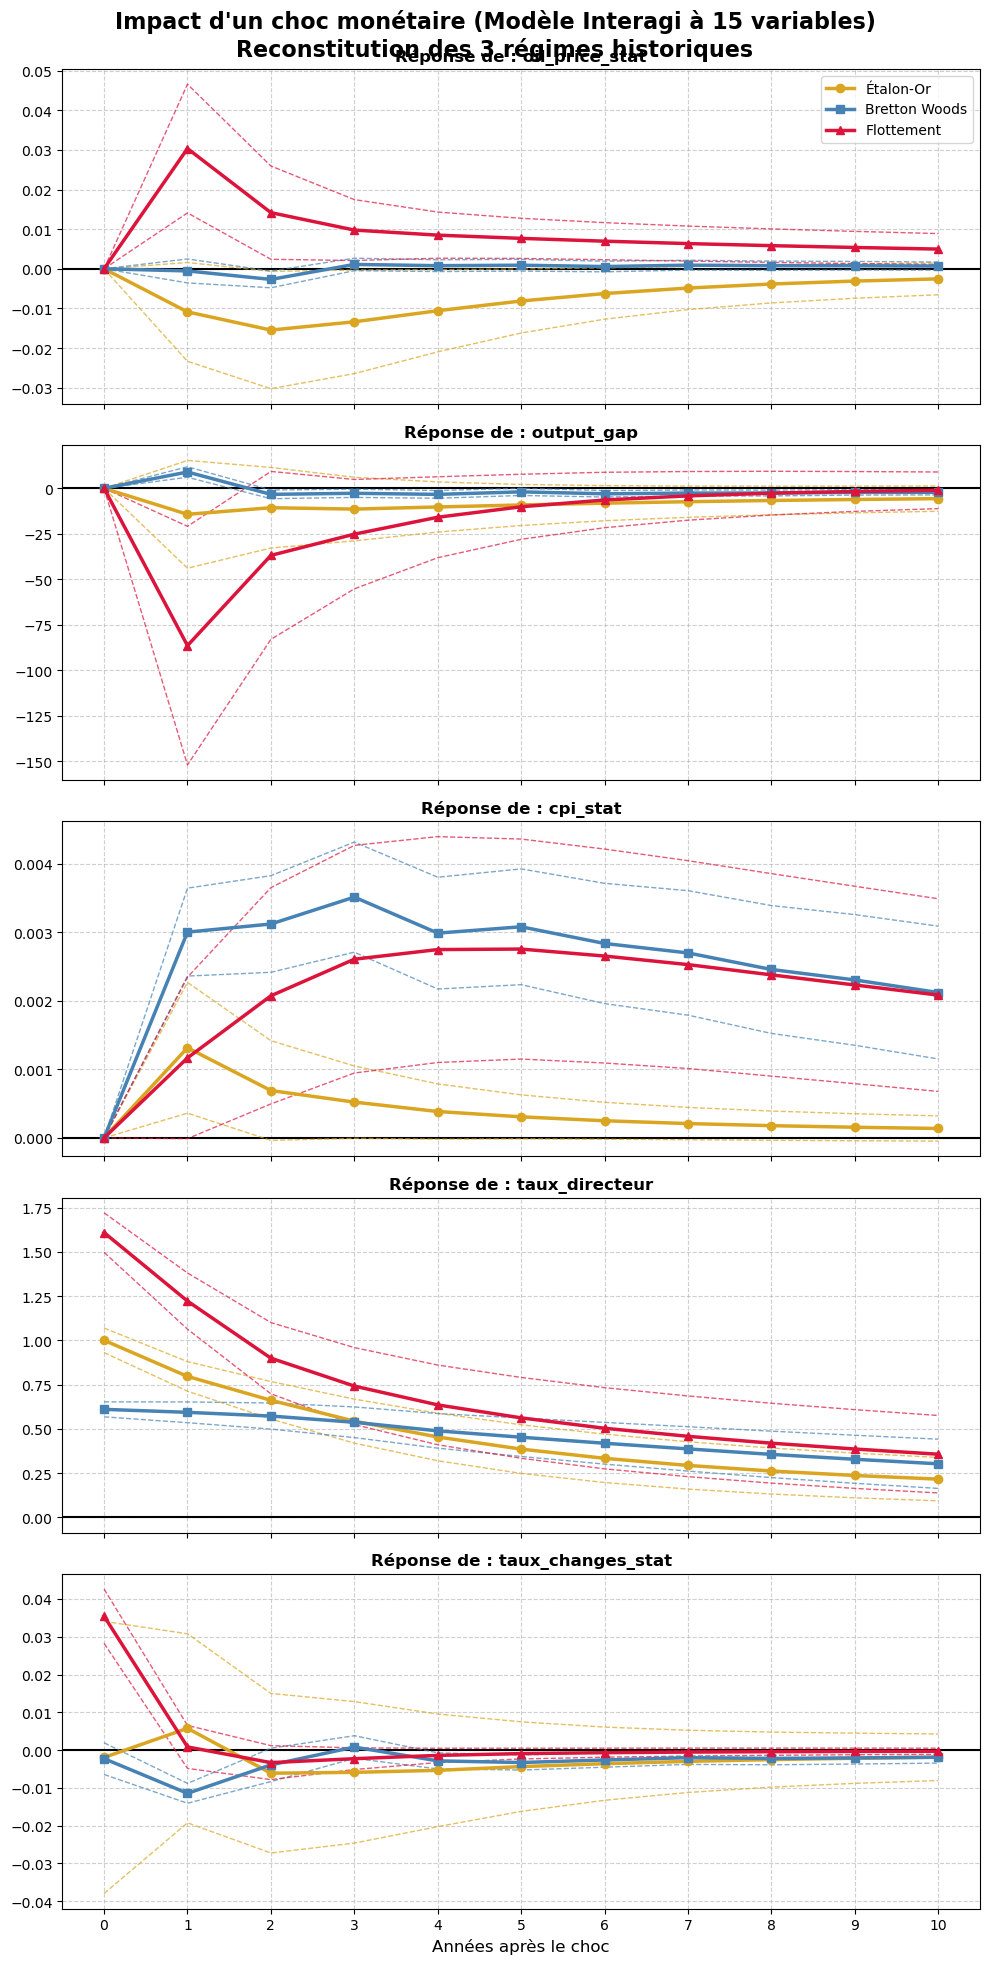

In [ ]:
#Ici j'essaie bien que Chat me dise que cela ne sert à rien (car cela reviens à estimer 3 modèle), de créer non seulement des dummies
# mais également de les faire interagire avec les variables de contrôle, comme on a vu en cours quoi.


import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR

# 1. On recrée nos Dummies de base 
df_detrended['dummy_gold'] = np.where(df_detrended['year'] < 1914, 1, 0)
df_detrended['dummy_bw'] = np.where((df_detrended['year'] >= 1945) & (df_detrended['year'] <= 1971), 1, 0)
df_detrended['dummy_float'] = np.where(df_detrended['year'] > 1971, 1, 0)

variables_base = ['oil_price_stat', 'output_gap', 'cpi_stat', 'taux_directeur', 'taux_changes_stat']
variables_interagies = []

# 2. On crée la grande boucle d'interaction
# On va multiplier CHAQUE variable par CHAQUE dummy.
# On passe donc de 5 variables à 15 variables. 
for var in variables_base:
    df_detrended[f'{var}_gold'] = df_detrended[var] * df_detrended['dummy_gold']
    df_detrended[f'{var}_bw'] = df_detrended[var] * df_detrended['dummy_bw']
    df_detrended[f'{var}_float'] = df_detrended[var] * df_detrended['dummy_float']
    variables_interagies.extend([f'{var}_gold', f'{var}_bw', f'{var}_float'])

df_interact = df_detrended.set_index('year')[variables_interagies]

#Ici j'estime le modèle et génère les IRF
print("Tentative d'estimation du VAR interagi à 15 variables...")

try:
    # On estime le modèle
    res_interact = VAR(df_interact).fit(1)
    print("Succès : Le modèle a été estimé !")
    
    horizon = 10
    irf_interact = res_interact.irf(horizon)
    
    #Je génère les graphs
    noms = res_interact.names 

    # Position des chocs 
    idx_choc_gold = noms.index('taux_directeur_gold')
    idx_choc_bw = noms.index('taux_directeur_bw')
    idx_choc_float = noms.index('taux_directeur_float')

    couleurs = {'Gold': 'goldenrod', 'BW': 'steelblue', 'Float': 'crimson'}
    marqueurs = {'Gold': 'o', 'BW': 's', 'Float': '^'}
    z = 1 # Intervalle à 68%

    fig, axes = plt.subplots(nrows=len(variables_base), ncols=1, figsize=(10, 20), sharex=True)
    fig.suptitle("Impact d'un choc monétaire (Modèle Interagi à 15 variables)\nReconstitution des 3 régimes historiques", 
                 fontsize=16, fontweight='bold', y=0.98)

    # Boucle pour générer chaque graphique
    for i, var_base in enumerate(variables_base):
        ax = axes[i]
        
        idx_rep_gold = noms.index(f'{var_base}_gold')
        idx_rep_bw = noms.index(f'{var_base}_bw')
        idx_rep_float = noms.index(f'{var_base}_float')
        
        # 1. Extraction Gold
        val_g = irf_interact.orth_irfs[:, idx_rep_gold, idx_choc_gold]
        se_g = irf_interact.stderr(orth=True)[:, idx_rep_gold, idx_choc_gold]
        low_g, up_g = val_g - z * se_g, val_g + z * se_g
        
        # 2. Extraction BW
        val_bw = irf_interact.orth_irfs[:, idx_rep_bw, idx_choc_bw]
        se_bw = irf_interact.stderr(orth=True)[:, idx_rep_bw, idx_choc_bw]
        low_bw, up_bw = val_bw - z * se_bw, val_bw + z * se_bw
        
        # 3. Extraction Float
        val_f = irf_interact.orth_irfs[:, idx_rep_float, idx_choc_float]
        se_f = irf_interact.stderr(orth=True)[:, idx_rep_float, idx_choc_float]
        low_f, up_f = val_f - z * se_f, val_f + z * se_f
        
        ax.axhline(0, color='black', linewidth=1.5)
        
        # Intervalles
        ax.plot(low_g, color=couleurs['Gold'], linestyle='--', linewidth=1, alpha=0.7)
        ax.plot(up_g, color=couleurs['Gold'], linestyle='--', linewidth=1, alpha=0.7)
        ax.plot(low_bw, color=couleurs['BW'], linestyle='--', linewidth=1, alpha=0.7)
        ax.plot(up_bw, color=couleurs['BW'], linestyle='--', linewidth=1, alpha=0.7)
        ax.plot(low_f, color=couleurs['Float'], linestyle='--', linewidth=1, alpha=0.7)
        ax.plot(up_f, color=couleurs['Float'], linestyle='--', linewidth=1, alpha=0.7)
        
        # Courbes
        ax.plot(val_g, label='Étalon-Or', color=couleurs['Gold'], linewidth=2.5, marker=marqueurs['Gold'])
        ax.plot(val_bw, label='Bretton Woods', color=couleurs['BW'], linewidth=2.5, marker=marqueurs['BW'])
        ax.plot(val_f, label='Flottement', color=couleurs['Float'], linewidth=2.5, marker=marqueurs['Float'])
        
        # Esthétique
        ax.set_title(f"Réponse de : {var_base}", fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.6)
        
        if i == 0:
            ax.legend(loc='upper right', fontsize=10)

    # Finitions
    plt.xlabel("Années après le choc", fontsize=12)
    plt.xticks(range(0, horizon + 1))
    plt.tight_layout()
    plt.subplots_adjust(top=0.95) 
    plt.show()

except np.linalg.LinAlgError:
    print("\nERREUR FATALE : Matrice singulière (LinAlgError).")
    print("Le modèle interagi contient trop de zéros pour que l'algorithme OLS puisse inverser la matrice.")
except Exception as e:
    print(f"\nUne autre erreur s'est produite : {e}")


Le problème : 
1. La variance est dilluée dans le deuxième code ce qui applatis mes courbes. 
2. WTF Cholesky en PLS : 
    Dans le Code 1 : Le modèle repose sur 3 petites boîtes bien propres. L'algorithme prend 5 variables, les classe dans l'ordre défini initialement (Pétrole -> Activité -> Prix -> Taux -> Change) et nettoie les chocs de manière logique.
    Dans le Code 2 : La structure se transforme en un "monstre" à 15 variables. L'algorithme construit une matrice géante de 15x15. Quand il applique Cholesky, il le fait sur l'ordre dans lequel les variables ont été créées : oil_gold, oil_bw, oil_float, output_gap_gold, etc.

Le nettoyage des chocs n'a plus aucun sens économique. Par exemple, le modèle essaie d'orthogonaliser le taux directeur de 1980 en le purgeant de l'effet du pétrole des années 1890. Les interdépendances mathématiques créent du "bruit" qui modifie la trajectoire des courbes.